 The best solution found:                                                                           
 [9.99951573 9.99853289 9.9983291 ]

 Objective function:
 -29.9963777224239


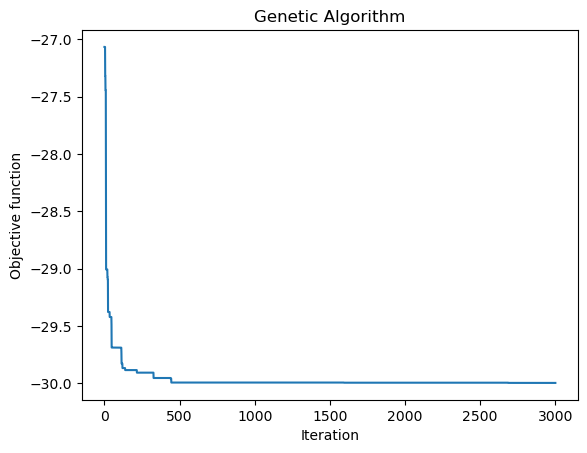

AttributeError: 'geneticalgorithm' object has no attribute 'ouput_dict'

In [1]:
import numpy as np
from geneticalgorithm import geneticalgorithm as ga

def f(X):
    return -np.sum(X)


varbound=np.array([[0,10]]*3)

algorithm_param = {'max_num_iteration': 3000,\
                   'population_size':100,\
                   'mutation_probability':0.1,\
                   'elit_ratio': 0.01,\
                   'crossover_probability': 0.5,\
                   'parents_portion': 0.3,\
                   'crossover_type':'uniform',\
                   'max_iteration_without_improv':None}

model=ga(function=f,\
            dimension=3,\
            variable_type='real',\
            variable_boundaries=varbound,\
            algorithm_parameters=algorithm_param)

model.run()

convergence=model.report
solution=model.ouput_dict

In [ ]:
import sys
sys.path.insert(0, '/home/nagle/final_version/squid-nn')
import tensorflow as tf  
import os
import numpy as np
import pandas as pd
from tensorflow import keras
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
sys.path.append('/home/nagle/final_version/residualbind')    
from residualbind import ResidualBind
import helper


normalization = 'log_norm'   # 'log_norm' or 'clip_norm'
ss_type = 'seq'     # 'seq', 'pu', or 'struct'
alphabet = ['A','C','G','U']

data_path = Path.home() / 'residualbind'/ 'data'/'RNAcompete_2013'/'rnacompete2013.h5'
results_path = helper.make_directory('/home/nagle/residualbind/results', 'rnacompete_2013')
save_path = '/home/nagle/residualbind/weights/log_norm_seq'

plot_path = helper.make_directory(save_path, 'FINAL')


experiment = 'RNCMPT00111' #VTS1
rbp_index = helper.find_experiment_index(data_path, experiment)
print('Analyzing: '+ experiment)

# load rbp dataset
train, valid, test = helper.load_rnacompete_data(data_path,
                                                     ss_type='seq',
                                                     normalization=normalization,
                                                     rbp_index=rbp_index)


# load residualbind model
input_shape = list(train['inputs'].shape)[1:]
num_class = 1
weights_path = os.path.join(save_path, experiment + '_weights.hdf5')
model = ResidualBind(input_shape, num_class, weights_path)
model.load_weights()

2025-07-18 10:34:40.612463: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-18 10:34:41.343288: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda-11.2/lib64
2025-07-18 10:34:41.343359: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda-11.2/lib64
2025-07-18 10:34:41.343365: W tensorflow/compiler/tf2tensorrt/utils/py_utils

Analyzing: RNCMPT00111


: 

1: Represent sequence as real integer values

In [ ]:
input_seq = "AUCGUAGCUGAC"

def convert_to_num(input_seq):
    